# CPWL operator timing against the SVD, tolerance-stopped
Timing against the SVD (exp4), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): every internal $\mathrm{Sgn}$ call inside the operator's sign form is run with `sign_map.make_sgn_ns_until` until it reaches a residual tolerance $\varepsilon$ instead of a fixed iteration count $K_D$. Both routes evaluate the same CPWL operator on the same matrix, against the exact operator read off a signed SVD (`cpwl_operator.spectral_reference`). Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_svd_timing import CPWLSvdTimingConfig, run_cpwl_svd_timing, cpwl_results_table
from experiments.svd_timing import time_table, speedup_table, cond_table  # same result layout as exp4
%matplotlib inline

In [ ]:
cfg = CPWLSvdTimingConfig(
    sizes=[64, 128, 256, 512], conds=[1e1], sigma_max=3.0, degrees=[1, 2, 3, 4],
    devices=["cuda", "cpu"], dtype=torch.float64,
    profile="clip",                        # which of the fields below are read depends on the profile
    alpha=-0.5, beta=0.5, gamma=0.3, a=0.2, mu=0.4, knots=None, vals=None,
    eps=1e-6,     # residual target for every internal sign call
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    power_iters=10, power_margin=1.1,
    time_unit="ms", time_round_digits=2,
    n_warmup=2, n_reps=10, cpu_threads=None, svd_driver=None, seed=0,
    run_svd=True,         # False: skip every SVD (no SVD timing, no errors)
    svd_only=False,       # True: time only the SVD, skip Newton-Schulz
    verbose=True,  # progress only, results are in the tables below
)
res = run_cpwl_svd_timing(cfg)

## Time against size and against $\sigma_{\min}$

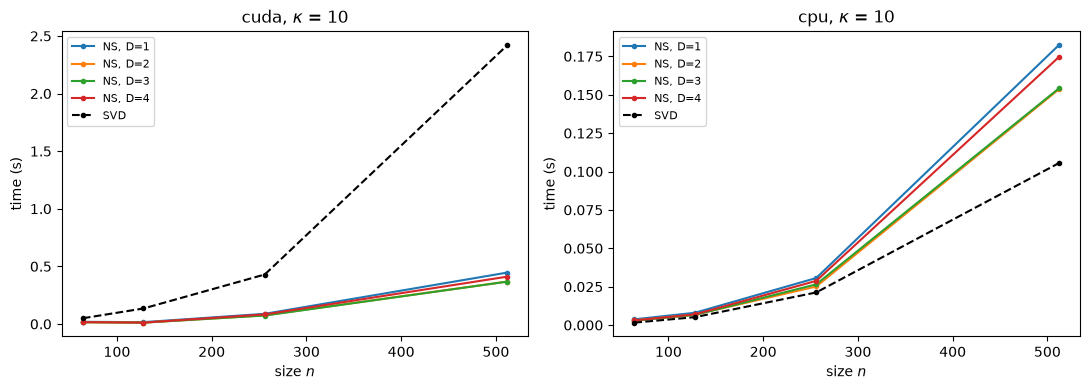

In [11]:
cond_plot = 1e1  # condition number shown in the time-vs-size panel and the tables
n_plot = 128     # size shown in the time-vs-cond panel and tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, cond_plot, ax=ax)
    ax.set_yscale("linear")
    ax.set_xscale("linear")
fig.tight_layout()

time (s), median ± std over 10 matrices: cuda, n = 128
smin  D=1              D=2               D=3                D=4               SVD             
0.01  0.0109 ± 0.0049  0.00932 ± 0.0038  0.00901 ± 0.00039  0.00895 ± 0.0004  0.0122 ± 0.00068



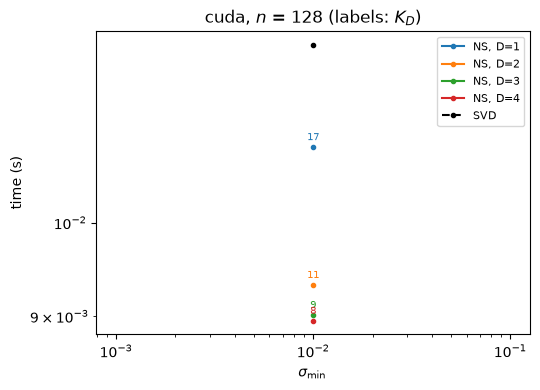

In [10]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_cond(res, device, n_plot, ax=ax)
fig.tight_layout()
for device in res["cfg"].devices:
    cond_table(res, device, n_plot)
    print()

## Tables
Time and speedup over the SVD-based evaluation at `cond_plot`, then, for every condition number $\kappa$, the relative Frobenius error against the exact CPWL operator, evaluation time, number of internal sign-map calls, and the largest iteration count any of those calls needed to reach $\varepsilon$, one row per degree $D$.

In [5]:
for device in res["cfg"].devices:
    time_table(res, device, cond_plot)
    print()
    speedup_table(res, device, cond_plot)
    print()
    for cond in cfg.conds:
        cpwl_results_table(res, device, 128, cond)
        print()

time (s), median ± std over 10 matrices: cuda, cond = 10
n    D=1              D=2               D=3               D=4               SVD            
64   0.0164 ± 0.0033  0.0136 ± 0.0028   0.0134 ± 0.002    0.0137 ± 0.00045  0.0496 ± 0.0046
128  0.0139 ± 0.0043  0.0109 ± 0.002    0.0101 ± 0.0025   0.0105 ± 0.0021   0.132 ± 0.0012 
256  0.0782 ± 0.0034  0.0653 ± 0.00087  0.0667 ± 0.00082  0.0736 ± 0.0014   0.425 ± 0.0025 
512  0.402 ± 0.0034   0.341 ± 0.0024    0.336 ± 0.0021    0.372 ± 0.002     2.39 ± 0.015   

speedup over the SVD (median times): cuda, cond = 10
n    D=1    D=2     D=3     D=4   
64   3.02x  3.64x   3.70x   3.61x 
128  9.50x  12.06x  13.07x  12.51x
256  5.44x  6.51x   6.38x   5.77x 
512  5.95x  7.01x   7.13x   6.43x 

CPWL operator (clip), tolerance eps = 1e-06, mean/max over 10 matrices: cuda, n = 128, cond = 10
     rel. Frobenius error  time       # sign calls  max K
D=1  3.92e-08              13.89 ms   3.0           18   
D=2  3.83e-08              10.94 ms   3.